In [1]:
# Se importan todas las librerías necesarias
import pandas as pd
import seaborn as sns
import numpy as np  
from matplotlib import pyplot as plt
import pickle

# Importante poner para que se muestren los gráficos
%matplotlib inline

# Semilla que se usará siempre para garantizar reproducibilidad
semilla = 123

# Directorio con los ficheros
dir_datasets = "./VulkanSimTrain/"

In [2]:
nombres_escenas = ["BATH", "BUNNY", "CAR", "CHSNT", "CRNVL", "FOX", "FRST", "LANDS", "PARK", "PARTY", "REF", "ROBOT", "SHIP", "SPNZA", "SPRNG", "WKND"]

datos = dict()

for nombre in nombres_escenas:
    print(f"Leyendo escena {nombre}")
    datos[nombre] = pd.read_csv(dir_datasets+nombre+"-frame0.txt",sep=",",header=None,names=["ID","Cycle","Address","IP","Cache_hit"])


Leyendo escena BATH


Leyendo escena BUNNY


Leyendo escena CAR


Leyendo escena CHSNT


Leyendo escena CRNVL


...

Leyendo escena REF


Leyendo escena ROBOT


Leyendo escena SHIP
Leyendo escena SPNZA


Leyendo escena SPRNG


Leyendo escena WKND


In [3]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].head())
    print("-"*80)

Escena: BATH

   ID  Cycle    Address     IP  Cache_hit
0   0  35655   c6abf000   1bc8          0
1   1  35679   c6abf000   1bc8          0
2   2  35900   c6abf000   1bc8          1
3   3  35901   c6abf000   1bc8          1
4   4  35912   c6abf000   1bc8          1
--------------------------------------------------------------------------------
Escena: BUNNY

   ID  Cycle    Address     IP  Cache_hit
0   0  36870   c2333b00   1bc8          0
1   1  36894   c2333b00   1bc8          0
2   2  38671   c2333b00   1bc8          1
3   3  38683   c2333b00   1bc8          1
4   4  38958   c2333b00   1bc8          0
--------------------------------------------------------------------------------
Escena: CAR

   ID  Cycle     Address     IP  Cache_hit
0   0  35698   1f049f900   1bc8          0
1   1  35722   1f049f900   1bc8          0
2   2  36087   1f049f900   1bc8          1
3   3  36111   1f049f900   1bc8          1
4   4  36220   1f049f900   1bc8          1
----------------------------------

In [4]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].dtypes)
    print("-"*80)

Escena: BATH

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: BUNNY

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CAR

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CHSNT

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CRNVL

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
----------------------------------

In [5]:
# Se pasa la columna Address de hexadecimal a decimal
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]["Address"] = datos[nombre]["Address"].apply(lambda x: int(str(x), 16))
    print("-"*80)

Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [6]:
# Se crea la columna Block_address dividiendo los valores de la
# columna Address entre 128
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Block_address'] = datos[nombre]['Address'].apply(lambda x: x//128)
    print("-"*80)


Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [7]:
# Se pasa la columna IP de hexadecimal a decimal, asignando -1 a los valores ffffffffffffffff
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['IP'] = datos[nombre]['IP'].apply(lambda x: int(x, 16) if x != "ffffffffffffffff" else -1)
    print("-"*80)

Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [8]:
# Se crea la columna Page_address dividiendo los valores de la
# columna Address entre 4096
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Page_address'] = datos[nombre]['Address'].apply(lambda x: x//4096)
    print("-"*80)

Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [9]:
# Se crea la columna Delta, que muestra, para cada Block_address,
# la diferencia con el Block_address anterior
# datos['Delta'] = datos['Block_address'].diff().fillna(0).astype(int)

In [10]:
datos["ROBOT"].head()

,ID,Cycle,Address,IP,Cache_hit,Block_address,Page_address
0,0,34605,8859649280,7112,0,69216010,2163000
1,1,34617,8859649280,7112,0,69216010,2163000
2,2,34990,8859649280,7112,1,69216010,2163000
3,3,35002,8859649280,7112,1,69216010,2163000
4,4,36965,8859649280,7112,1,69216010,2163000


In [11]:
datos["ROBOT"].dtypes

ID               int64
Cycle            int64
Address          int64
IP               int64
Cache_hit        int64
Block_address    int64
Page_address     int64
dtype: object

In [12]:
datos["ROBOT"].describe()

,ID,Cycle,Address,IP,Cache_hit,Block_address,Page_address
count,2.849572e+07,2.849572e+07,2.849572e+07,28495718.0,2.849572e+07,2.849572e+07,2.849572e+07
mean,1.424786e+07,1.929569e+07,6.157825e+09,7112.0,3.737972e-01,4.810800e+07,1.503375e+06
std,8.226005e+06,1.120788e+07,1.160418e+09,0.0,4.838108e-01,9.065762e+06,2.833051e+05
min,0.000000e+00,3.460500e+04,6.706499e+08,7112.0,0.000000e+00,5.239452e+06,1.637320e+05
25%,7.123929e+06,9.583870e+06,5.574011e+09,7112.0,0.000000e+00,4.354696e+07,1.360842e+06
50%,1.424786e+07,1.929918e+07,6.140094e+09,7112.0,0.000000e+00,4.796949e+07,1.499046e+06
75%,2.137179e+07,2.895864e+07,6.827944e+09,7112.0,1.000000e+00,5.334332e+07,1.666978e+06
max,2.849572e+07,4.109267e+07,8.859686e+09,7112.0,1.000000e+00,6.921630e+07,2.163009e+06


In [13]:
# Función para mostrar un histograma de una columna
def mostrar_columna(escena:str, columna:str, limite_absoluto:int = None):
    plt.figure(figsize=(8,5))
    if limite_absoluto is not None:
        sns.histplot(data=datos[escena][abs(datos[escena].Page_address_delta) < limite_absoluto], x=columna, bins=100)
    else:
        sns.histplot(data=datos[escena], x=columna, bins=100)
    plt.title(f'Distribución de {columna} para {escena}')
    plt.xlabel(columna)
    plt.ylabel('Recuento')
    plt.ticklabel_format(style="plain")
    plt.show()

In [14]:
for escena in nombres_escenas:
    next_page_same_counter = 0
    next_page_different_counter = 0

    k = 5

    for i in range(len(datos[escena])-k):
        if datos[escena]["Page_address"][i] == datos[escena]["Page_address"][i+k]:
            next_page_same_counter+=1
        else:
            next_page_different_counter+=1

    print(f"Datos para la escena {escena}:")
    print(f"Saltos a la misma página: {next_page_same_counter} ({100*next_page_same_counter/(next_page_same_counter+next_page_different_counter)}%)")
    print(f"Saltos a otra página: {next_page_different_counter} ({100*next_page_different_counter/(next_page_same_counter+next_page_different_counter)}%)")
    print("="*80)

Datos para la escena BATH:
Saltos a la misma página: 191230 (5.29877845187444%)
Saltos a otra página: 3417715 (94.70122154812556%)


Datos para la escena BUNNY:
Saltos a la misma página: 118263 (6.115471191152493%)
Saltos a otra página: 1815570 (93.8845288088475%)


Datos para la escena CAR:
Saltos a la misma página: 222061 (4.445468089306141%)
Saltos a otra página: 4773161 (95.55453191069385%)


Datos para la escena CHSNT:
Saltos a la misma página: 102624 (4.58969411878356%)
Saltos a otra página: 2133342 (95.41030588121644%)


Datos para la escena CRNVL:
Saltos a la misma página: 165429 (4.590705201850168%)
Saltos a otra página: 3438135 (95.40929479814983%)


...

Datos para la escena ROBOT:
Saltos a la misma página: 2142938 (7.520211899944388%)
Saltos a otra página: 26352775 (92.47978810005561%)


Datos para la escena SHIP:
Saltos a la misma página: 22552 (8.332471217652188%)
Saltos a otra página: 248100 (91.66752878234782%)


Datos para la escena SPNZA:
Saltos a la misma página: 119524 (5.042319558119942%)
Saltos a otra página: 2250893 (94.95768044188006%)


Datos para la escena SPRNG:
Saltos a la misma página: 42268 (4.6431870885389035%)
Saltos a otra página: 868055 (95.35681291146109%)


Datos para la escena WKND:
Saltos a la misma página: 147315 (21.512685789054036%)
Saltos a otra página: 537467 (78.48731421094597%)


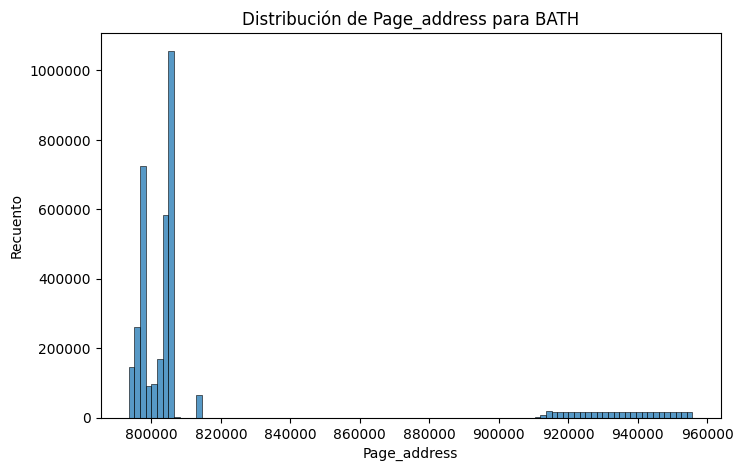

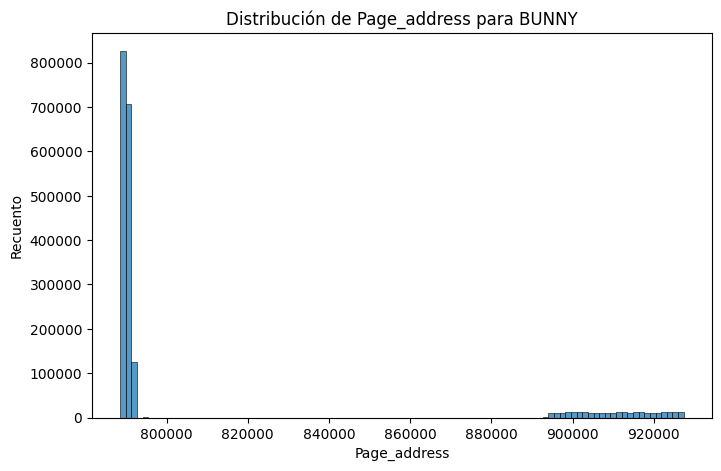

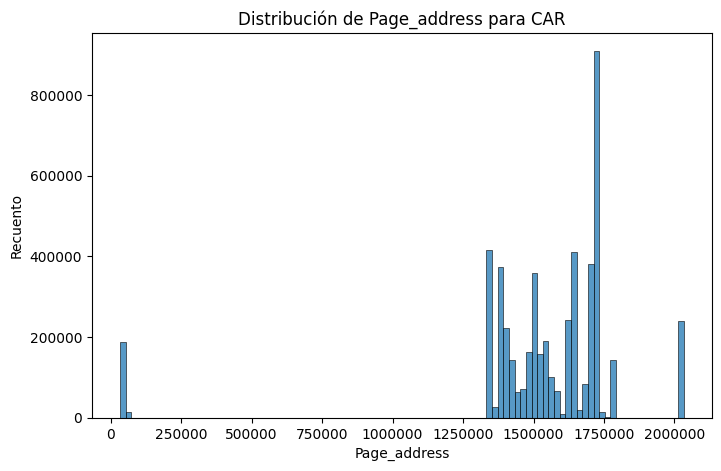

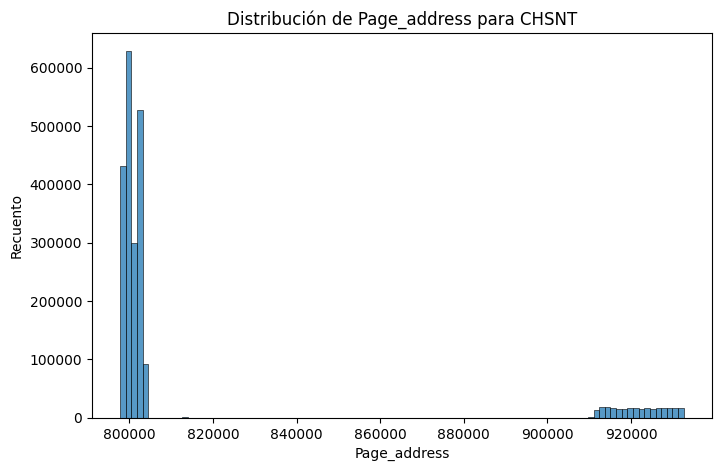

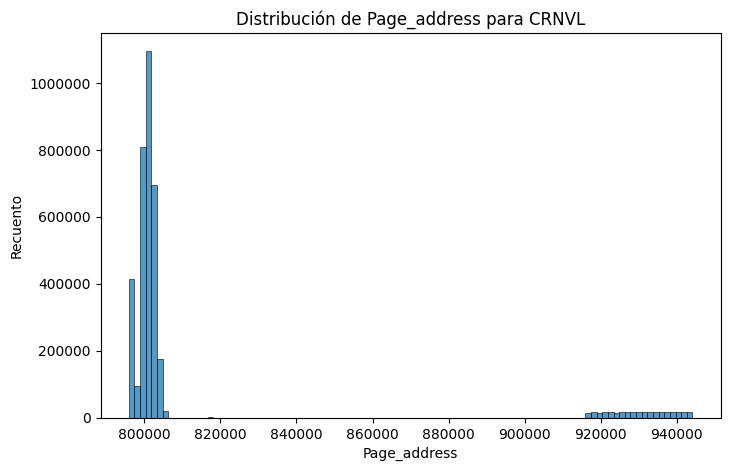

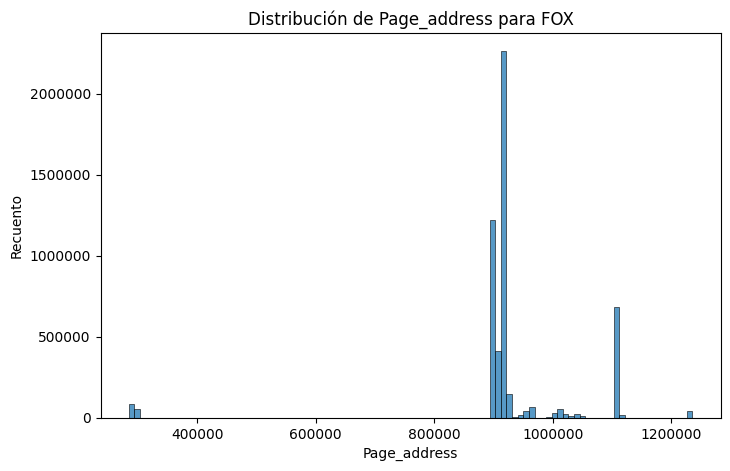

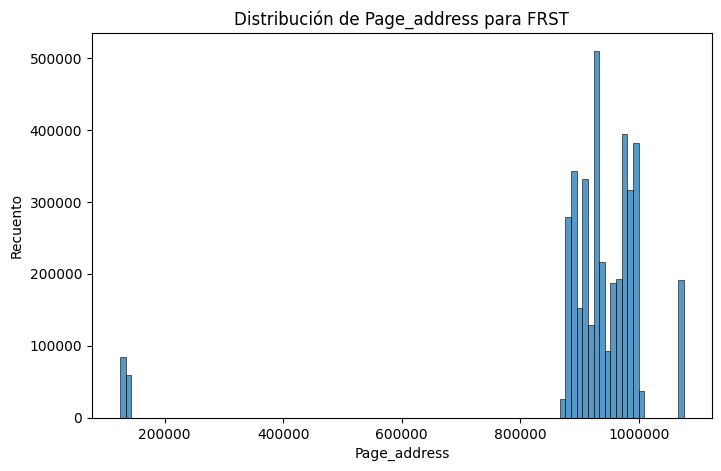

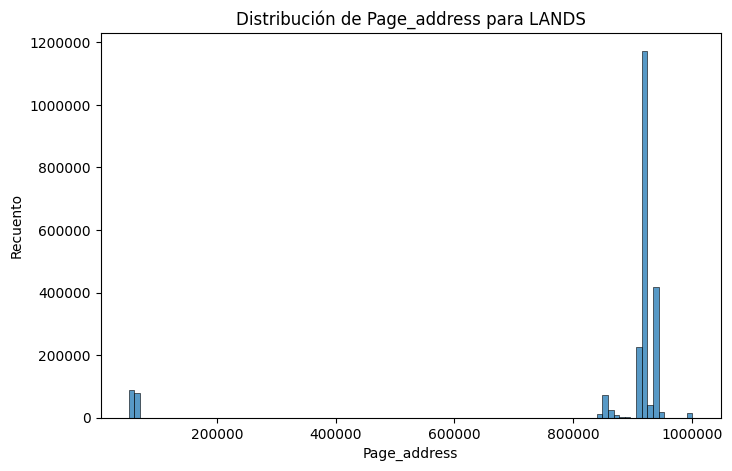

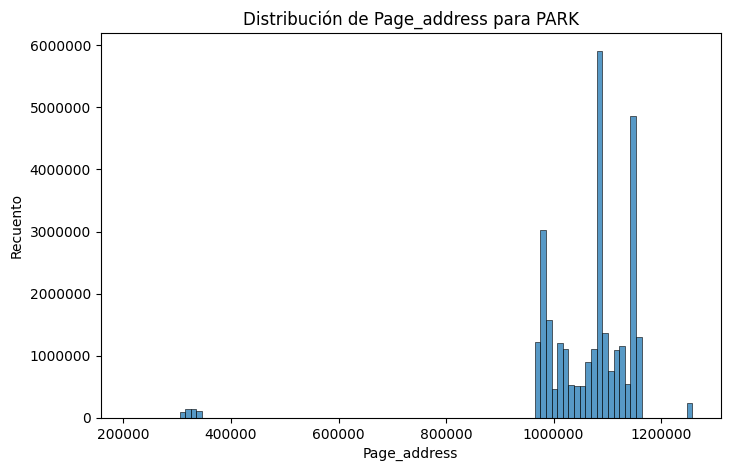

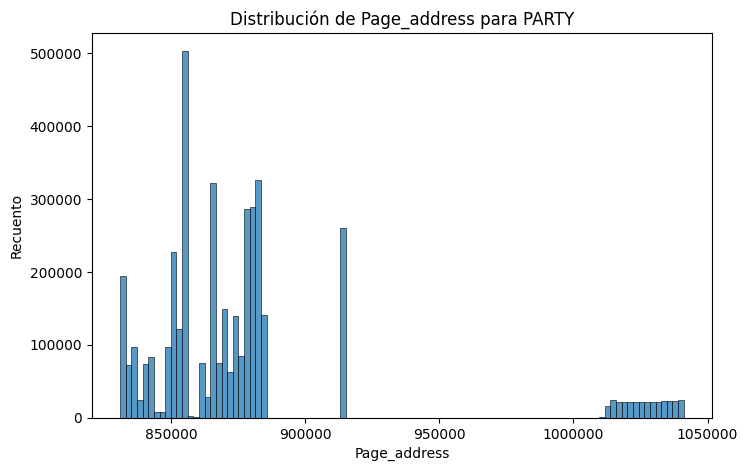

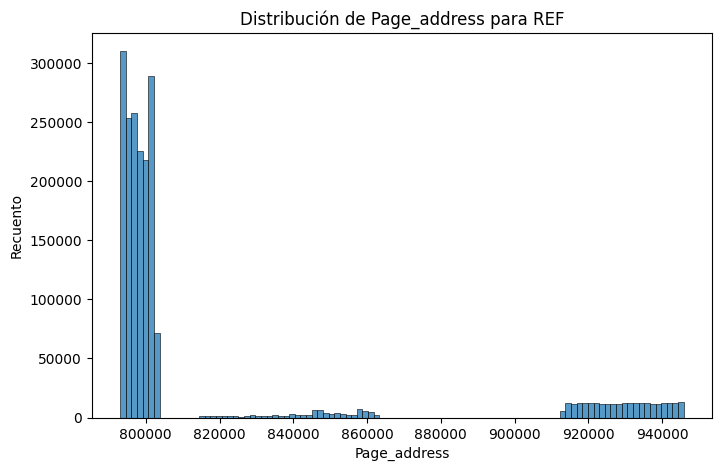

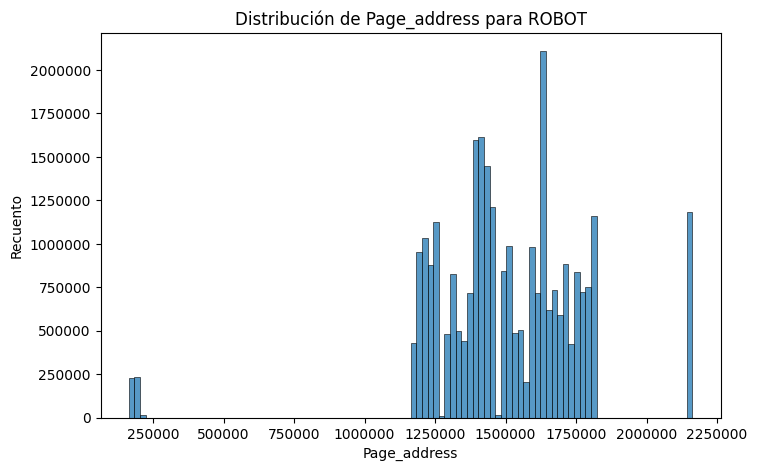

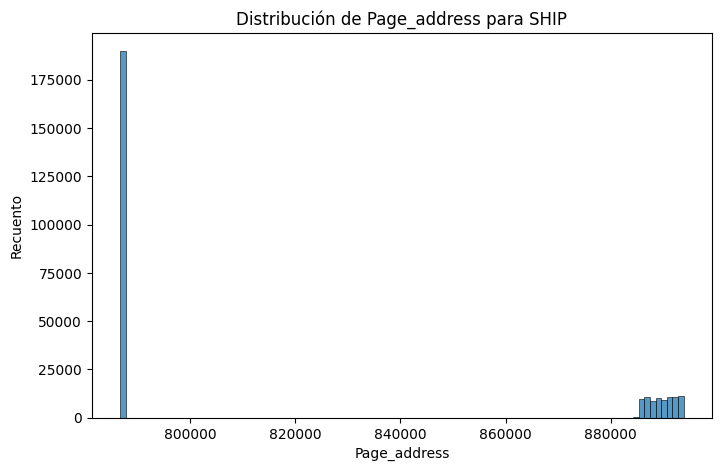

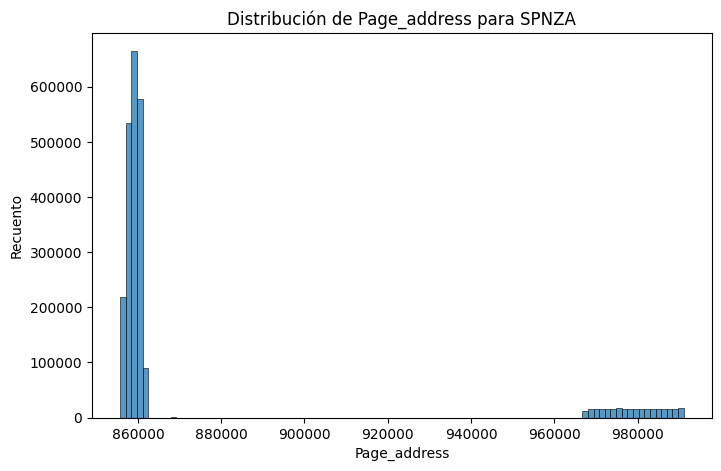

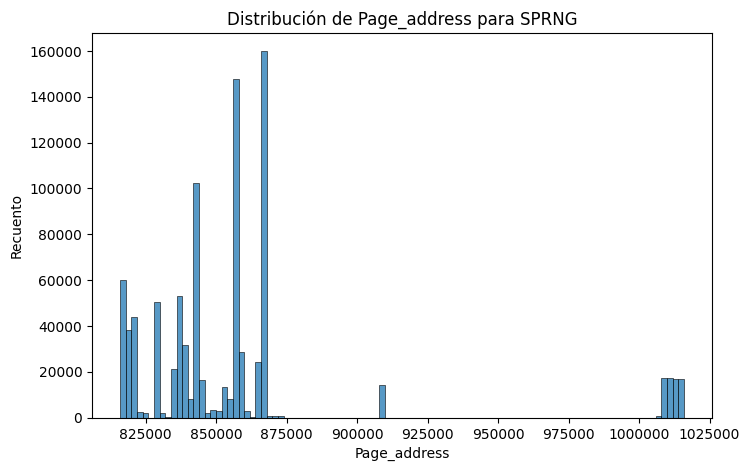

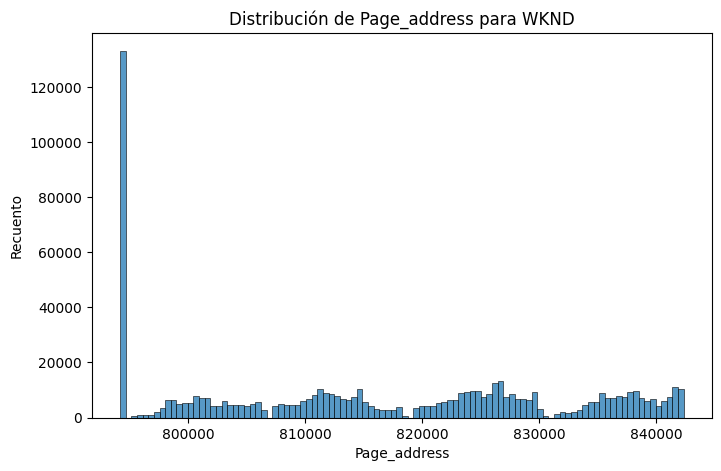

In [15]:
for escena in nombres_escenas:
    mostrar_columna(escena,"Page_address")

In [16]:
for escena in nombres_escenas:
    num_paginas_unicas = datos[escena]["Page_address"].nunique()
    print(f'Número de páginas únicas en la escena {escena}: {num_paginas_unicas} ({100*num_paginas_unicas/datos[escena]["Page_address"].count()}%)')

Número de páginas únicas en la escena BATH: 45652 (1.264966264425941%)
Número de páginas únicas en la escena BUNNY: 30779 (1.5916017784323195%)
Número de páginas únicas en la escena CAR: 85455 (1.710733065784598%)
Número de páginas únicas en la escena CHSNT: 21552 (0.9638765440160002%)
Número de páginas únicas en la escena CRNVL: 31348 (0.8699153533621806%)
Número de páginas únicas en la escena FOX: 35355 (0.6829305417819049%)
Número de páginas únicas en la escena FRST: 51638 (1.315235829593443%)
Número de páginas únicas en la escena LANDS: 25850 (1.1890343890824104%)


Número de páginas únicas en la escena PARK: 110773 (0.37153235656655176%)
Número de páginas únicas en la escena PARTY: 42100 (1.0400719206027378%)
Número de páginas únicas en la escena REF: 36469 (1.8548347310670195%)


Número de páginas únicas en la escena ROBOT: 191903 (0.6734450418129488%)
Número de páginas únicas en la escena SHIP: 6846 (2.529400680566178%)
Número de páginas únicas en la escena SPNZA: 26568 (1.1208130872899424%)
Número de páginas únicas en la escena SPRNG: 18479 (2.0299276744206485%)
Número de páginas únicas en la escena WKND: 789 (0.11521830875878193%)


In [17]:
class entrada_ptt:
    def __init__(self, prediccion):
        self.prediccion = prediccion
        self.confianza = 1

In [18]:
historias = [1,2,3,4,5,6,7,8,9,10]

# La clave es la historia. El valor es una lista con los
# porcentajes para cada escena
porcentaje_predicciones_correctas = dict()

for historia in historias:
    print(f"HISTORIA {historia}")
    print("="*30)

    porcentaje_predicciones_correctas[historia] = []

    for escena in nombres_escenas:
        # La PTT ahora no guarda correspondencias entre
        # páginas pasadas y la página futura. Ahora guarda
        # correspondencias entre deltas pasados y el delta futuro
        ptt = dict()

        k = 5

        predicciones_correctas = 0
        predicciones_erroneas = 0

        for i in range(historia,len(datos[escena])-k):
            
            # Estas son las páginas que se tendrán en cuenta para calcular los deltas
            paginas_historia = tuple(datos[escena]["Page_address"][i-historia:i+1])

            # Estos son los deltas entre páginas
            deltas = []

            for j in range(1,len(paginas_historia)):
                pagina_actual = paginas_historia[j]
                pagina_pasada = paginas_historia[j-1]
                delta = pagina_actual-pagina_pasada
                deltas.append(delta)
            
            # La lista de deltas se pasa a una tupla para poder usarla
            # como clave en el diccionario
            deltas = tuple(deltas)

            #print("-"*30)

            #print(f"Páginas de historia: {paginas_historia}")
            #print(f"Deltas: {deltas}")

            if deltas in ptt:
                # Si hay coincidencia, se utiliza el delta predicho
                # que hay en la PTT
                delta_predicho = ptt[deltas]
                #print(f"Entrada de la PTT: (Predicción: {ptt[deltas].prediccion}, confianza: {ptt[deltas].confianza})")
            else:
                # Si no hay coincidencia, se considera que se
                # seguirá en la misma página (delta 0)
                delta_predicho = 0
                #print("No hay entrada en la PTT")

            # Se calcula el delta real
            delta_real = (datos[escena]["Page_address"][i+k] - datos[escena]["Page_address"][i])

            #print(f"Página siguiente real: {datos[escena]["Page_address"][i+k]}")
            #print(f"Delta real: {delta_real}")

            # Si el delta entre la página que hay 5 accesos después y la página actual es correcto,
            # se aumenta el contador de predicciones correctas. Si no, se aumenta el contador de
            # predicciones erróneas
            if delta_real == delta_predicho:
                predicciones_correctas+=1
                #print("La predicción fue correcta")
            else:
                predicciones_erroneas+=1
                #print("La predicción fue incorrecta")
            
            # Si la predicción viene de una entrada de la PTT y se
            # ha predicho correctamente, se aumenta la confianza
            if delta_real == delta_predicho and deltas in ptt:
                ptt[deltas].confianza += 1
                #print(f"La confianza aumenta de {ptt[deltas].confianza-1} a {ptt[deltas].confianza}")
            
            # Si la predicción viene de una entrada de la PTT y se
            # ha predicho incorrectamente, se disminuye la confianza,
            # eliminando la entrada si la confianza llega a 0
            elif delta_real != delta_predicho and deltas in ptt:
                ptt[deltas].confianza -= 1
                #print(f"La confianza disminuye de {ptt[deltas].confianza+1} a {ptt[deltas].confianza}")
                if ptt[deltas].confianza == 0:
                    ptt.pop(deltas)
                    #print("Como la confianza ha llegado a 0, se elimina la entrada de la PTT")
            
            # Después de actualizar las confianzas puede que se haya
            # liberado una entrada por llegar a confianza 0. También
            # puede que no haya habido una entrada con esta clave
            # en primere lugar. Sea como sea, se añade la entrada si
            # no hay
            if deltas not in ptt:
                ptt[deltas] = entrada_ptt(delta_real)
                #print(f"No hay entrada en la PTT con esta clave. Creando entrada: (Predicción: {ptt[deltas].prediccion}, confianza: {ptt[deltas].confianza})")

        print(f"Predicciones correctas en la escena {escena}: {predicciones_correctas} ({100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas)}%)")
        porcentaje_predicciones_correctas[historia].append(100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas))
    print()

HISTORIA 1


Predicciones correctas en la escena BATH: 9038 (0.25043336776630504%)


Predicciones correctas en la escena BUNNY: 7854 (0.4061366240707569%)


Predicciones correctas en la escena CAR: 45425 (0.90936917505752%)


Predicciones correctas en la escena CHSNT: 3264 (0.14597724025197176%)


...

Predicciones correctas en la escena ROBOT: 1951417 (6.848109695696927%)


Predicciones correctas en la escena SHIP: 22315 (8.245209538800333%)


Predicciones correctas en la escena SPNZA: 119418 (5.037869024180235%)


Predicciones correctas en la escena SPRNG: 42079 (4.622476005505798%)


Predicciones correctas en la escena WKND: 108701 (15.874042747074938%)



In [19]:
with open('porcentaje_predicciones_correctas_deltas_confianza_en_reemplazo.p', 'wb') as fp:
    pickle.dump(porcentaje_predicciones_correctas, fp, protocol=pickle.HIGHEST_PROTOCOL)

In [20]:
with open('porcentaje_predicciones_correctas_deltas_confianza_en_reemplazo.p', 'rb') as fp:
    porcentaje_predicciones_correctas = pickle.load(fp)

In [21]:
# Source - https://stackoverflow.com/a
# Posted by willeM_ Van Onsem, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-19, License - CC BY-SA 4.0

import numpy as np

def geo_mean(iterable):
    a = np.array(iterable)
    return a.prod()**(1.0/len(a))

In [22]:
for h in porcentaje_predicciones_correctas.keys():
    media_geometrica = geo_mean(porcentaje_predicciones_correctas[h])
    porcentaje_predicciones_correctas[h].append(media_geometrica)
    print(f"Media geométrica con historia {h}: {media_geometrica}")

Media geométrica con historia 1: 0.354144277422615
Media geométrica con historia 2: 4.146219976691221
Media geométrica con historia 3: 4.81748981144052
Media geométrica con historia 4: 5.101629858885774
Media geométrica con historia 5: 5.303179988996364
Media geométrica con historia 6: 5.442042135896412
Media geométrica con historia 7: 5.54934872008392
Media geométrica con historia 8: 5.630611205946586
Media geométrica con historia 9: 5.695651593348076
Media geométrica con historia 10: 5.748307835998279


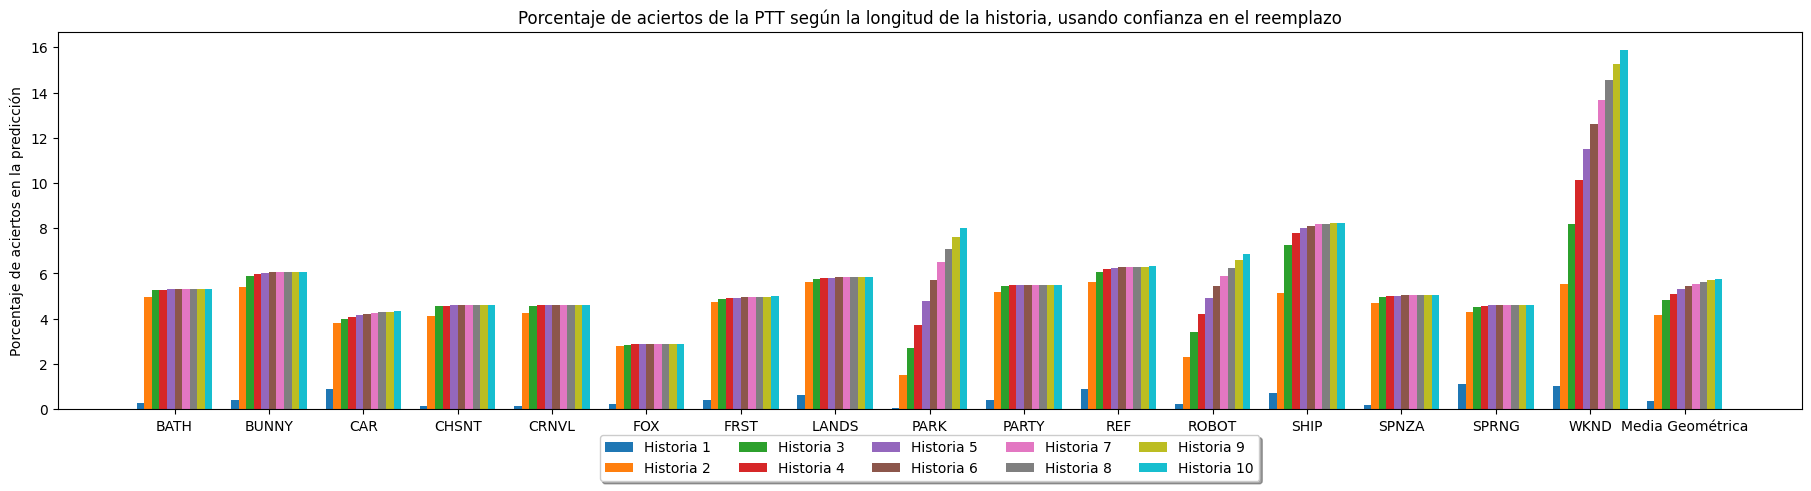

In [23]:
import matplotlib.pyplot as plt
import numpy as np

nombres_escenas = ["BATH", "BUNNY", "CAR", "CHSNT", "CRNVL", "FOX", "FRST", "LANDS", "PARK", "PARTY", "REF", "ROBOT", "SHIP", "SPNZA", "SPRNG", "WKND", "Media Geométrica"]

# Localización de cada etiqueta
x = np.arange(len(nombres_escenas))

# Anchura de las barras
width = 0.08

multiplier = 0

fig, ax = plt.subplots(layout='constrained')

fig.set_figwidth(18)

for historia, medidas in porcentaje_predicciones_correctas.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, medidas, width, label=f"Historia {historia}")
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Porcentaje de aciertos en la predicción')
ax.set_title('Porcentaje de aciertos de la PTT según la longitud de la historia, usando confianza en el reemplazo')
ax.set_xticks(x + width*4.5, nombres_escenas)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

plt.show()